# Linear Regression Baseline

## 1. Imports

In [2]:
from pathlib import Path
import csv
import json
import math
import random
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")
import matplotlib.pyplot as plt
import torch
from torch import nn
from sklearn.model_selection import GroupKFold
from IPython.display import display


## 2. Configuration

In [3]:
DATASET_MODE = "default"  # or "flopoco" for one-off AST-only run
DATA_PATH = Path("../data/merged_vector_dataset.csv")
RESULTS_ROOT = Path("../results/linear_regression")
if DATASET_MODE == "flopoco":
    DATA_PATH = Path("../data/merged_vector_dataset_flopoco.csv")
    RESULTS_ROOT = Path("../results/linear_regression_flopoco")
NUM_FOLDS = 5
USE_FIXED_SEED = True
RANDOM_SEED = 123
LEARNING_RATE = 1e-2
LOSS_NAME = "mse"
# LOSS_NAME = "smooth_l1"
SMOOTH_L1_BETA = 1.0
EPOCHS = 300

AST_FEATURE_COLUMNS = [
    "total_input_bits",
    "total_output_bits",
    "total_register_bits",
    "total_logic_operator_bits",
    "total_adder_sub_bits",
    "total_multiplier_bits",
    "total_comparator_bits",
    "total_multiplexer_bits",
    "total_shift_bits",
    "total_division_bits",
    "total_memory_write_addr_bits",
    "total_memory_write_addr_width",
    "total_memory_read_addr_bits",
    "total_memory_read_addr_width",
    "average_tree_depth",
    "average_wire_width",
]

NUMERIC_CONFIG_COLUMNS = [
    "clock_period_ns_cfg",
    "max_fanout_cfg",
    "max_transition_ns_cfg",
    "max_capacitance_ff_cfg",
    "fanout_load_cfg",
]

CATEGORICAL_CONFIG_COLUMNS = ["abc_fast_cfg", "flow_mode"]
if DATASET_MODE == "flopoco":
    NUMERIC_CONFIG_COLUMNS = []
    CATEGORICAL_CONFIG_COLUMNS = []
TARGET_COLUMNS = ["worst_slack_ns", "total_negative_slack_ns"]
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)
print("Dataset mode:", DATASET_MODE)

if USE_FIXED_SEED:
    random.seed(RANDOM_SEED)
    np.random.seed(RANDOM_SEED)
    torch.manual_seed(RANDOM_SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(RANDOM_SEED)
    print("Using fixed random seed:", RANDOM_SEED)
else:
    print("Using non-deterministic random behavior")

valid_loss_names = {"mse", "smooth_l1"}
if LOSS_NAME not in valid_loss_names:
    raise ValueError(f"LOSS_NAME must be one of {sorted(valid_loss_names)}")
print("Training loss:", LOSS_NAME)


Using device: cpu
Dataset mode: default
Using fixed random seed: 123
Training loss: mse


## 3. Data Loading

In [4]:
with DATA_PATH.open("r", newline="") as f:
    rows = list(csv.DictReader(f))

RESULTS_ROOT.mkdir(parents=True, exist_ok=True)
run_num = 1
while True:
    RUN_DIR = RESULTS_ROOT / f"run_{run_num:03d}"
    if not RUN_DIR.exists():
        RUN_DIR.mkdir()
        break
    run_num += 1

rows_df = pd.DataFrame(rows)
AST_FEATURE_COLUMNS = [
    col for col in AST_FEATURE_COLUMNS
    if col in rows_df.columns and rows_df[col].astype(str).str.strip().ne("").any()
]
if not AST_FEATURE_COLUMNS:
    raise ValueError("No AST feature columns were found in the merged dataset.")

print(f"Loaded {len(rows)} rows from {DATA_PATH}")
print(f"Using AST feature columns: {AST_FEATURE_COLUMNS}")
print(f"Saving run artifacts to {RUN_DIR.resolve()}")
rows[:2]



Loaded 13536 rows from ..\data\merged_vector_dataset.csv
Using AST feature columns: ['total_input_bits', 'total_output_bits', 'total_register_bits', 'total_logic_operator_bits', 'total_adder_sub_bits', 'total_multiplier_bits', 'total_comparator_bits', 'total_multiplexer_bits', 'total_shift_bits', 'total_division_bits', 'total_memory_write_addr_bits', 'total_memory_write_addr_width', 'total_memory_read_addr_bits', 'total_memory_read_addr_width', 'average_tree_depth', 'average_wire_width']
Saving run artifacts to C:\Users\DeAndre\Documents\Spring 2026\nndl\final_project\PPA-Estimation-Project\modeling\results\linear_regression\run_085


[{'design_name': 'i2c',
  'design_id': 'iwls05_0006',
  'recipe_id': 'abcfast_clk0p1_fo16_tr0p16_cap100_fload1',
  'flow_mode': 'full',
  'total_input_bits': '19',
  'total_output_bits': '14',
  'total_register_bits': '128',
  'total_logic_operator_bits': '186',
  'total_adder_sub_bits': '19',
  'total_multiplier_bits': '0',
  'total_comparator_bits': '1350',
  'total_multiplexer_bits': '514',
  'total_shift_bits': '0',
  'total_division_bits': '0',
  'total_memory_write_addr_bits': '0',
  'total_memory_write_addr_width': '0',
  'total_memory_read_addr_bits': '0',
  'total_memory_read_addr_width': '0',
  'average_tree_depth': '6.401617250673854',
  'average_wire_width': '4.707949790794979',
  'worst_slack_ns': '-0.380054',
  'total_negative_slack_ns': '-31.437371',
  'run_utc': '2026-04-06T14:32:37+00:00',
  'run_id': 'i2c__abcfast_clk0p1_fo16_tr0p16_cap100_fload1',
  'top_module': 'i2c_master_top',
  'clock_port': 'wb_clk_i',
  'abc_fast_cfg': 'True',
  'clock_period_ns_cfg': '0.1',
 

## 3.1 Design Feature Outlier View


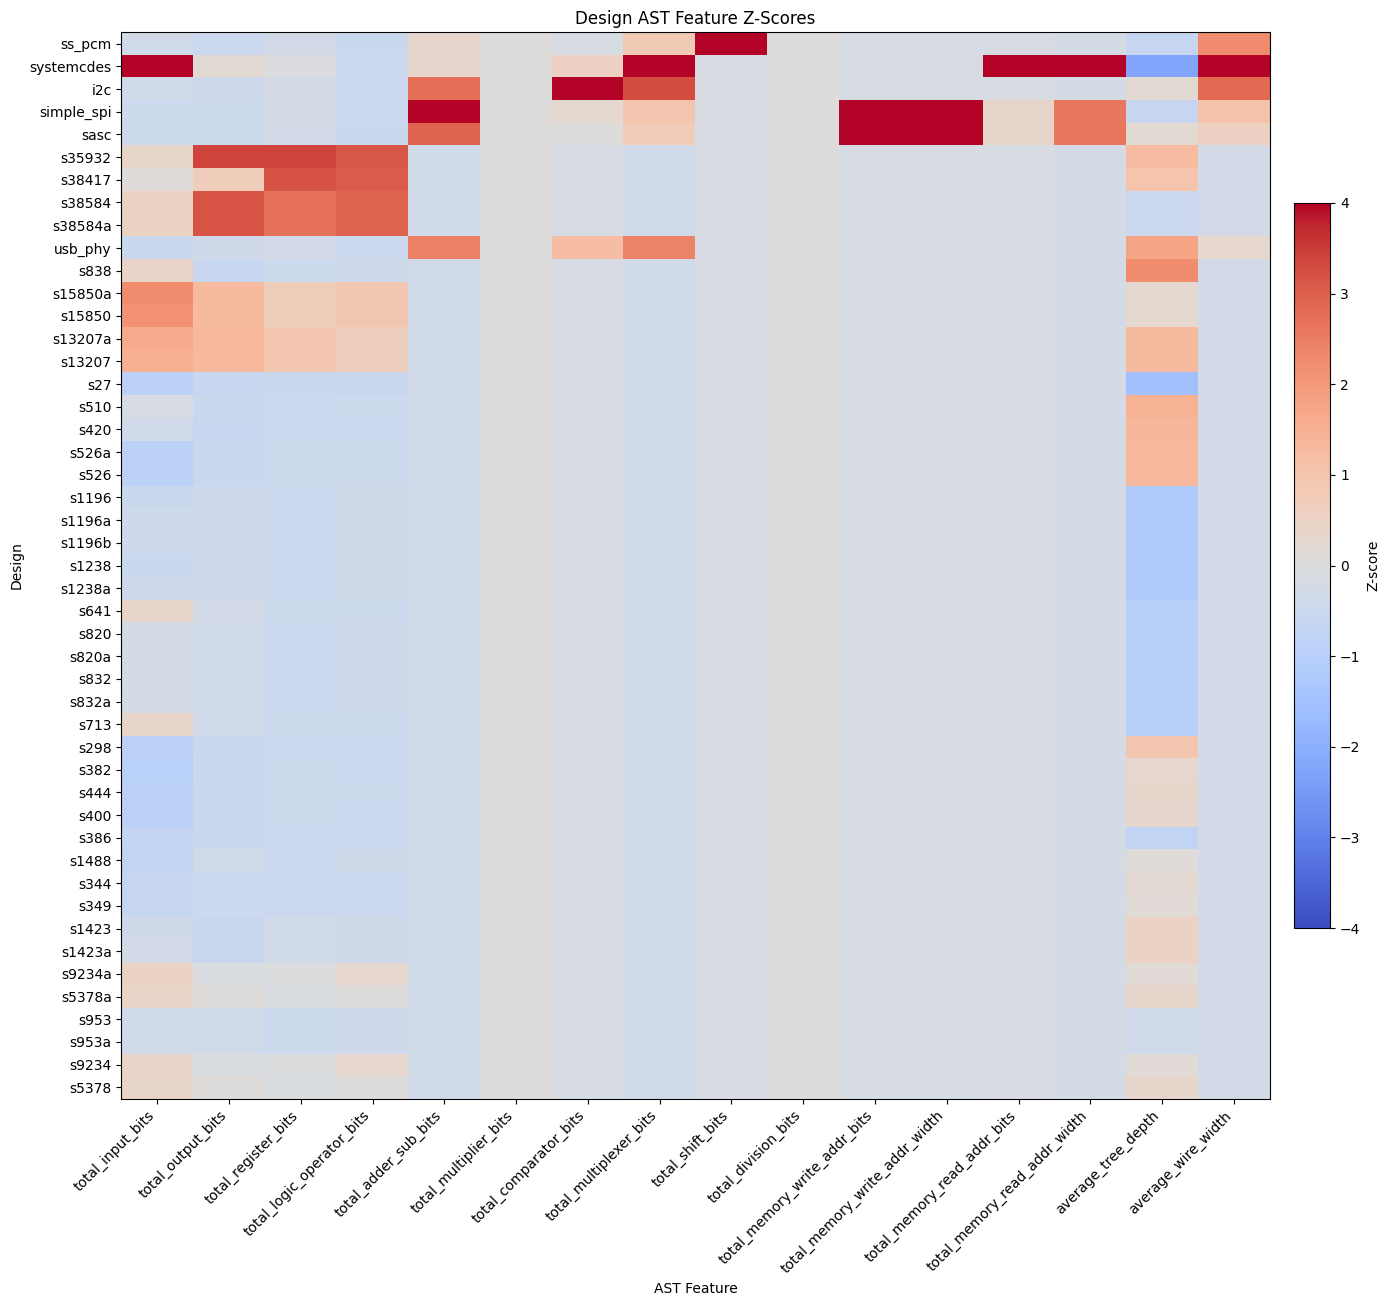

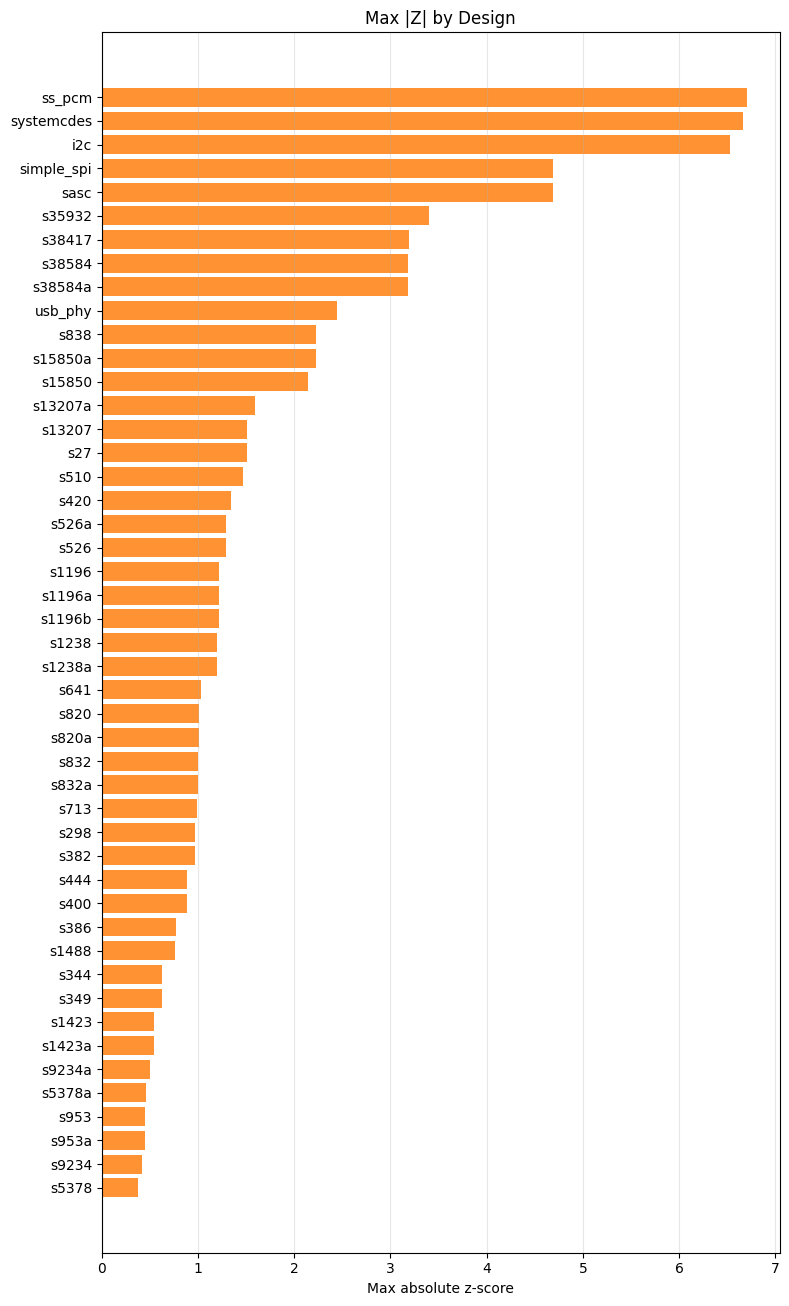

Top design feature outliers:


,design_name,max_abs_zscore,mean_abs_zscore
0,ss_pcm,6.7098,0.8377
1,systemcdes,6.6644,1.9413
2,i2c,6.5251,1.1278
3,simple_spi,4.6927,1.3369
4,sasc,4.6927,1.1686
5,s35932,3.4000,0.8533
6,s38417,3.1918,0.6323
7,s38584,3.1783,0.7450
8,s38584a,3.1783,0.7450
9,usb_phy,2.4431,0.6693


In [5]:
design_feature_df = pd.DataFrame(rows).groupby("design_name")[AST_FEATURE_COLUMNS].first().reset_index()

feature_matrix = design_feature_df[AST_FEATURE_COLUMNS].apply(pd.to_numeric, errors="coerce").fillna(0.0).astype(np.float32)
feature_mean = feature_matrix.mean(axis=0)
feature_std = feature_matrix.std(axis=0)
feature_std[feature_std == 0.0] = 1.0
feature_z = (feature_matrix - feature_mean) / feature_std

outlier_table = pd.DataFrame({
    "design_name": design_feature_df["design_name"],
    "max_abs_zscore": feature_z.abs().max(axis=1),
    "mean_abs_zscore": feature_z.abs().mean(axis=1),
})
outlier_table = outlier_table.sort_values(["max_abs_zscore", "mean_abs_zscore"], ascending=False).reset_index(drop=True)

ordered_designs = outlier_table["design_name"].tolist()
ordered_feature_z = feature_z.set_index(design_feature_df["design_name"]).loc[ordered_designs]

heat_values = np.clip(ordered_feature_z.to_numpy(dtype=np.float32), -4.0, 4.0)
fig, ax = plt.subplots(figsize=(14, max(8, len(ordered_designs) * 0.28)))
im = ax.imshow(heat_values, aspect="auto", cmap="coolwarm", vmin=-4.0, vmax=4.0)
ax.set_title("Design AST Feature Z-Scores")
ax.set_xlabel("AST Feature")
ax.set_ylabel("Design")
ax.set_xticks(np.arange(len(AST_FEATURE_COLUMNS)))
ax.set_xticklabels(AST_FEATURE_COLUMNS, rotation=45, ha="right")
ax.set_yticks(np.arange(len(ordered_designs)))
ax.set_yticklabels(ordered_designs)
fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02, label="Z-score")
plt.tight_layout()
heatmap_plot_path = RUN_DIR / "design_feature_zscore_heatmap.png"
fig.savefig(heatmap_plot_path, dpi=200, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(8, max(8, len(ordered_designs) * 0.28)))
ax.barh(ordered_designs, outlier_table["max_abs_zscore"], color="tab:orange", alpha=0.85)
ax.invert_yaxis()
ax.set_title("Max |Z| by Design")
ax.set_xlabel("Max absolute z-score")
ax.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
outlier_bar_plot_path = RUN_DIR / "design_feature_outlier_bars.png"
fig.savefig(outlier_bar_plot_path, dpi=200, bbox_inches="tight")
plt.show()

feature_z_table = pd.concat([design_feature_df[["design_name"]], feature_z], axis=1)
outlier_csv_path = RUN_DIR / "design_feature_outliers.csv"
outlier_z_csv_path = RUN_DIR / "design_feature_zscores.csv"
outlier_table.to_csv(outlier_csv_path, index=False)
feature_z_table.to_csv(outlier_z_csv_path, index=False)

print("Top design feature outliers:")
display(outlier_table.head(15).round(4))



## 4. Partition into Train/Test Split

Randomly shuffle rows and perform index-based split

In [6]:
rows_df = pd.DataFrame(rows)
design_groups = rows_df["design_name"].astype(str).to_numpy()
unique_designs = sorted(rows_df["design_name"].astype(str).unique().tolist())

if len(unique_designs) < 2:
    raise ValueError("Need at least 2 designs for GroupKFold.")

n_splits = min(NUM_FOLDS, len(unique_designs))
if n_splits < 2:
    raise ValueError("Need at least 2 folds for GroupKFold.")

cv = GroupKFold(n_splits=n_splits)
fold_splits = list(cv.split(rows_df, groups=design_groups))

fold_rows = []
for fold_number, (train_idx, test_idx) in enumerate(fold_splits, start=1):
    train_designs = sorted(rows_df.iloc[train_idx]["design_name"].astype(str).unique().tolist())
    test_designs = sorted(rows_df.iloc[test_idx]["design_name"].astype(str).unique().tolist())
    fold_rows.append({
        "fold": fold_number,
        "train_rows": len(train_idx),
        "test_rows": len(test_idx),
        "train_design_count": len(train_designs),
        "test_design_count": len(test_designs),
        "train_designs": ", ".join(train_designs),
        "test_designs": ", ".join(test_designs),
    })

fold_info_table = pd.DataFrame(fold_rows)

print("Split mode: GroupKFold by design_name")
print("Requested folds:", NUM_FOLDS)
print("Using folds:", n_splits)
print("Total rows:", len(rows_df))
print("Total designs:", len(unique_designs))
print("Fold layout:")
display(fold_info_table)


Split mode: GroupKFold by design_name
Requested folds: 5
Using folds: 5
Total rows: 13536
Total designs: 47
Fold layout:


,fold,train_rows,test_rows,train_design_count,test_design_count,train_designs,test_designs
0,1,10656,2880,37,10,"i2c, s1196a, s1196b, s1238, s1238a, s13207a, s...","s1196, s13207, s15850, s349, s38584a, s510, s6..."
1,2,10656,2880,37,10,"s1196, s1196a, s1196b, s1238, s13207, s13207a,...","i2c, s1238a, s1488, s344, s38584, s444, s5378a..."
2,3,10944,2592,38,9,"i2c, s1196, s1196a, s1196b, s1238a, s13207, s1...","s1238, s1423a, s298, s38417, s420, s5378, s820..."
3,4,10944,2592,38,9,"i2c, s1196, s1196a, s1238, s1238a, s13207, s13...","s1196b, s1423, s27, s382, s400, s526a, s820, s..."
4,5,10944,2592,38,9,"i2c, s1196, s1196b, s1238, s1238a, s13207, s14...","s1196a, s13207a, s15850a, s35932, s386, s526, ..."


## 5. Build Feature And Target Matrices

In [7]:
def build_xy(train_rows, test_rows):
    train_df = pd.DataFrame(train_rows)
    test_df = pd.DataFrame(test_rows)

    feature_cols = AST_FEATURE_COLUMNS + NUMERIC_CONFIG_COLUMNS

    x_train_num = train_df[feature_cols].apply(pd.to_numeric, errors="coerce").fillna(0.0).astype(np.float32)
    x_test_num = test_df[feature_cols].apply(pd.to_numeric, errors="coerce").fillna(0.0).astype(np.float32)

    train_cat_parts = []
    test_cat_parts = []
    cat_feature_names = []

    for col in CATEGORICAL_CONFIG_COLUMNS:
        train_one_hot = pd.get_dummies(train_df[col].astype(str), prefix=col)
        test_one_hot = pd.get_dummies(test_df[col].astype(str), prefix=col)
        test_one_hot = test_one_hot.reindex(columns=train_one_hot.columns, fill_value=0)

        train_cat_parts.append(train_one_hot)
        test_cat_parts.append(test_one_hot)
        cat_feature_names.extend(train_one_hot.columns.tolist())

    if train_cat_parts:
        x_train_cat = pd.concat(train_cat_parts, axis=1)
        x_test_cat = pd.concat(test_cat_parts, axis=1)
        x_train_df = pd.concat([x_train_num, x_train_cat], axis=1)
        x_test_df = pd.concat([x_test_num, x_test_cat], axis=1)
    else:
        x_train_df = x_train_num.copy()
        x_test_df = x_test_num.copy()

    y_train = train_df[TARGET_COLUMNS].apply(pd.to_numeric, errors="coerce").fillna(0.0).astype(np.float32).to_numpy()
    y_test = test_df[TARGET_COLUMNS].apply(pd.to_numeric, errors="coerce").fillna(0.0).astype(np.float32).to_numpy()

    all_feature_names = feature_cols + cat_feature_names
    return (
        x_train_df.to_numpy(dtype=np.float32),
        x_test_df.to_numpy(dtype=np.float32),
        y_train,
        y_test,
        all_feature_names,
    )



## 6. Train Linear Regression

Train using a singular PyTorch linear layer. COuld use closed form, but keeping linear regression and MLP notebooks uniform

In [8]:
import copy


def calc_r2_1d(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    if ss_tot == 0:
        return 0.0
    return 1.0 - (ss_res / ss_tot)


def get_metrics(y_true, y_pred):
    diff = y_pred - y_true
    mae = np.mean(np.abs(diff), axis=0)
    rmse = np.sqrt(np.mean(diff ** 2, axis=0))
    ss_res = np.sum((y_true - y_pred) ** 2, axis=0)
    ss_tot = np.sum((y_true - y_true.mean(axis=0)) ** 2, axis=0)
    r2 = 1.0 - np.divide(ss_res, ss_tot, out=np.zeros_like(ss_res), where=ss_tot != 0)
    return {"mae": mae, "rmse": rmse, "r2": r2}


def make_loss():
    if LOSS_NAME == "mse":
        return nn.MSELoss()
    return nn.SmoothL1Loss(beta=SMOOTH_L1_BETA)


loss_history_by_target = {name: [] for name in TARGET_COLUMNS}
train_r2_history_by_target = {name: [] for name in TARGET_COLUMNS}
test_r2_history_by_target = {name: [] for name in TARGET_COLUMNS}
fold_metric_rows = []
prediction_rows = []
fold_feature_rows = []
training_summary_rows = []
best_run_by_target = {}

oof_truth = rows_df[TARGET_COLUMNS].astype(np.float32).to_numpy()
oof_pred = np.full_like(oof_truth, np.nan, dtype=np.float32)

for fold_number, (train_idx, test_idx) in enumerate(fold_splits, start=1):
    print()
    print(f"Starting fold {fold_number}/{n_splits}")

    train_rows = rows_df.iloc[train_idx].to_dict("records")
    test_rows = rows_df.iloc[test_idx].to_dict("records")

    x_train, x_test, y_train, y_test, feature_columns = build_xy(train_rows, test_rows)
    fold_feature_rows.append({"fold": fold_number, "encoded_feature_count": len(feature_columns)})

    train_mean = x_train.mean(axis=0)
    train_std = x_train.std(axis=0)
    train_std[train_std == 0.0] = 1.0

    x_train = (x_train - train_mean) / train_std
    x_test = (x_test - train_mean) / train_std

    x_train_tensor = torch.tensor(x_train, dtype=torch.float32, device=DEVICE)
    x_test_tensor = torch.tensor(x_test, dtype=torch.float32, device=DEVICE)

    fold_train_pred = np.zeros_like(y_train)
    fold_test_pred = np.zeros_like(y_test)

    for target_idx, target_name in enumerate(TARGET_COLUMNS):
        print(f"  Training target: {target_name}")

        y_train_target = y_train[:, target_idx].astype(np.float32)
        y_test_target = y_test[:, target_idx].astype(np.float32)
        y_train_tensor = torch.tensor(y_train_target.reshape(-1, 1), dtype=torch.float32, device=DEVICE)

        model = nn.Linear(len(feature_columns), 1).to(DEVICE)
        optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
        loss_fn = make_loss()

        loss_list = []
        train_r2_list = []
        test_r2_list = []

        best_epoch = 0
        best_test_r2 = -np.inf
        best_state = copy.deepcopy(model.state_dict())
        best_train_pred = None
        best_test_pred = None

        for epoch in range(1, EPOCHS + 1):
            model.train()
            optimizer.zero_grad()
            pred_train = model(x_train_tensor)
            loss = loss_fn(pred_train, y_train_tensor)
            loss.backward()
            optimizer.step()

            loss_list.append(float(loss.item()))

            model.eval()
            with torch.no_grad():
                train_pred_now = model(x_train_tensor).cpu().numpy().reshape(-1)
                test_pred_now = model(x_test_tensor).cpu().numpy().reshape(-1)

            train_r2_now = calc_r2_1d(y_train_target, train_pred_now)
            test_r2_now = calc_r2_1d(y_test_target, test_pred_now)
            train_r2_list.append(train_r2_now)
            test_r2_list.append(test_r2_now)

            if test_r2_now > best_test_r2:
                best_test_r2 = test_r2_now
                best_epoch = epoch
                best_state = copy.deepcopy(model.state_dict())
                best_train_pred = train_pred_now.copy()
                best_test_pred = test_pred_now.copy()

            if epoch == 1 or epoch % 50 == 0 or epoch == EPOCHS:
                print(f"    Epoch {epoch:03d} | train_loss={loss.item():.6f} | test_r2={test_r2_now:.4f}")

        model.load_state_dict(best_state)
        if target_name not in best_run_by_target or best_test_r2 > best_run_by_target[target_name]["best_test_r2"]:
            best_run_by_target[target_name] = {
                "fold": int(fold_number),
                "best_test_r2": float(best_test_r2),
                "input_dim": int(len(feature_columns)),
                "state_dict": {k: v.detach().cpu().clone() for k, v in best_state.items()},
                "sample_input": x_test[:1].copy(),
                "sample_design_name": str(test_rows[0]["design_name"]),
                "sample_true_value": float(y_test[0, target_idx]),
            }
        fold_train_pred[:, target_idx] = best_train_pred
        fold_test_pred[:, target_idx] = best_test_pred

        loss_history_by_target[target_name].append(loss_list)
        train_r2_history_by_target[target_name].append(train_r2_list)
        test_r2_history_by_target[target_name].append(test_r2_list)
        training_summary_rows.append({
            "fold": fold_number,
            "target": target_name,
            "best_epoch": int(best_epoch),
            "best_test_r2": float(best_test_r2),
            "completed_epoch": int(EPOCHS),
        })

    oof_pred[test_idx] = fold_test_pred

    for row_index, row, pred, truth in zip(test_idx, test_rows, fold_test_pred, y_test):
        prediction_rows.append({
            "row_index": int(row_index),
            "fold": fold_number,
            "design_name": row["design_name"],
            "recipe_id": row["recipe_id"],
            "pred_worst_slack_ns": float(pred[0]),
            "true_worst_slack_ns": float(truth[0]),
            "wns_error": float(pred[0] - truth[0]),
            "pred_total_negative_slack_ns": float(pred[1]),
            "true_total_negative_slack_ns": float(truth[1]),
            "tns_error": float(pred[1] - truth[1]),
        })

    split_pairs = [("train", y_train, fold_train_pred), ("test", y_test, fold_test_pred)]
    for split_name, y_true_split, y_pred_split in split_pairs:
        scores = get_metrics(y_true_split, y_pred_split)
        for target_idx, target_name in enumerate(TARGET_COLUMNS):
            fold_metric_rows.append({
                "fold": fold_number,
                "split": split_name,
                "target": target_name,
                "mae": float(scores["mae"][target_idx]),
                "rmse": float(scores["rmse"][target_idx]),
                "r2": float(scores["r2"][target_idx]),
            })

training_summary_table = pd.DataFrame(training_summary_rows)

print()
print("Finished all folds.")
print("OOF predictions shape:", oof_pred.shape)
print("Encoded feature counts by fold:")
display(pd.DataFrame(fold_feature_rows))




Starting fold 1/5
  Training target: worst_slack_ns
    Epoch 001 | train_loss=0.844018 | test_r2=-2.1812
    Epoch 050 | train_loss=0.038774 | test_r2=0.8322
    Epoch 100 | train_loss=0.025455 | test_r2=0.8961
    Epoch 150 | train_loss=0.025099 | test_r2=0.9047
    Epoch 200 | train_loss=0.024976 | test_r2=0.9101
    Epoch 250 | train_loss=0.024870 | test_r2=0.9148
    Epoch 300 | train_loss=0.024783 | test_r2=0.9188
  Training target: total_negative_slack_ns
    Epoch 001 | train_loss=4086.758301 | test_r2=-0.0986
    Epoch 050 | train_loss=3944.654541 | test_r2=-0.0595
    Epoch 100 | train_loss=3817.109619 | test_r2=-0.0250
    Epoch 150 | train_loss=3701.731934 | test_r2=0.0063
    Epoch 200 | train_loss=3596.185791 | test_r2=0.0348
    Epoch 250 | train_loss=3499.493896 | test_r2=0.0611
    Epoch 300 | train_loss=3410.960938 | test_r2=0.0853

Starting fold 2/5
  Training target: worst_slack_ns
    Epoch 001 | train_loss=0.758773 | test_r2=-8.7586
    Epoch 050 | train_loss=0.0

,fold,encoded_feature_count
0,1,23
1,2,23
2,3,23
3,4,23
4,5,23


## 6.1 Training Loss Curve

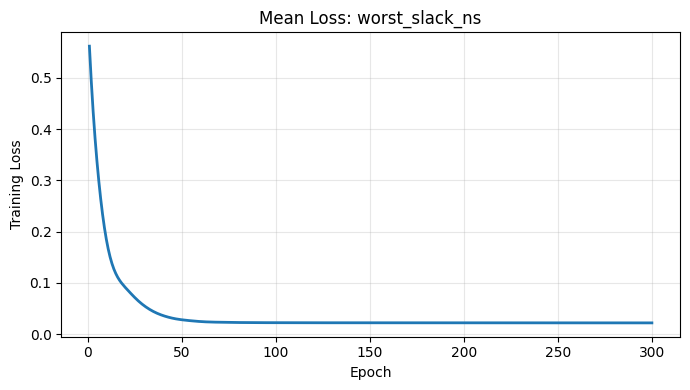

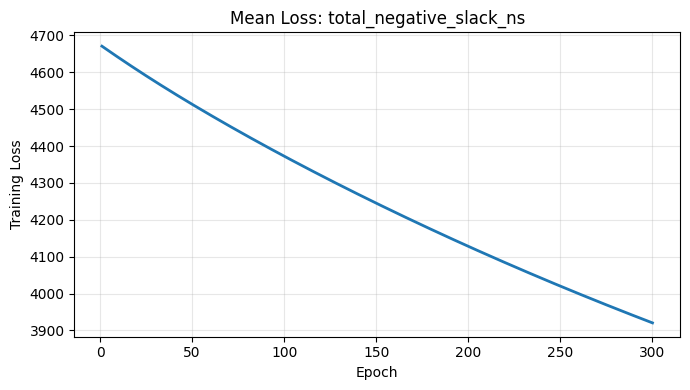

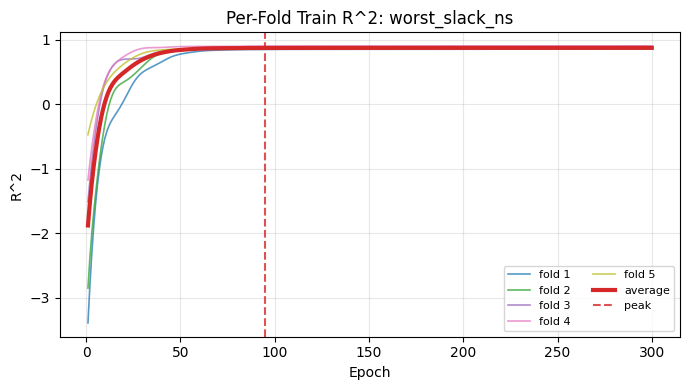

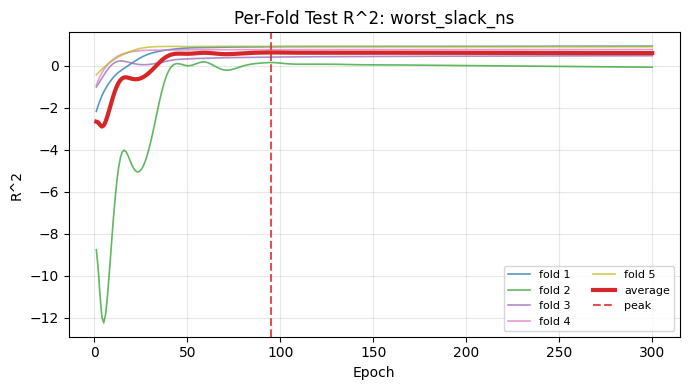

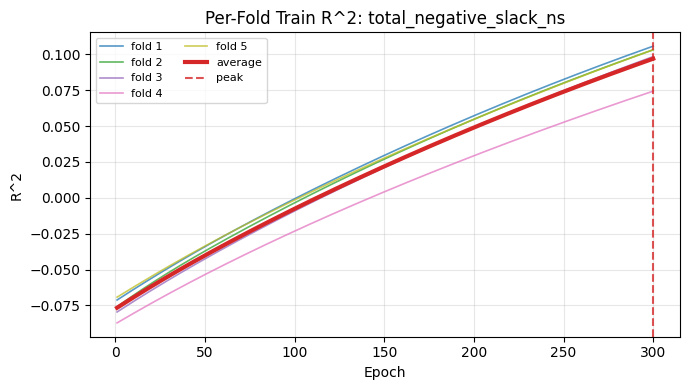

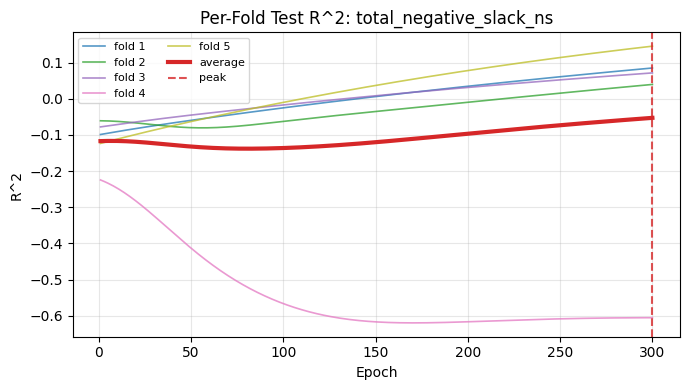

Peak summary below per-fold R^2 plot:


,target,peak_of_average_curve_r2,peak_of_average_curve_epoch,mean_fold_peak_r2,std_fold_peak_r2,mean_fold_peak_epoch
0,worst_slack_ns,0.6208,95,0.6445,0.3236,164.8
1,total_negative_slack_ns,-0.0526,300,0.0236,0.1439,240.2


In [9]:
r2_history_df = pd.DataFrame({"epoch": np.arange(1, EPOCHS + 1)})
for target_name in TARGET_COLUMNS:
    loss_matrix = np.array(loss_history_by_target[target_name], dtype=np.float32)
    train_r2_matrix = np.array(train_r2_history_by_target[target_name], dtype=np.float32)
    test_r2_matrix = np.array(test_r2_history_by_target[target_name], dtype=np.float32)

    r2_history_df[f"mean_loss_{target_name}"] = loss_matrix.mean(axis=0)
    r2_history_df[f"mean_train_r2_{target_name}"] = train_r2_matrix.mean(axis=0)
    r2_history_df[f"mean_test_r2_{target_name}"] = test_r2_matrix.mean(axis=0)

peak_epoch_by_target = {}
peak_test_r2_by_target = {}
for target_name in TARGET_COLUMNS:
    peak_idx = int(r2_history_df[f"mean_test_r2_{target_name}"].idxmax())
    peak_epoch_by_target[target_name] = int(r2_history_df.loc[peak_idx, "epoch"])
    peak_test_r2_by_target[target_name] = float(r2_history_df.loc[peak_idx, f"mean_test_r2_{target_name}"])

for target_name in TARGET_COLUMNS:
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(r2_history_df["epoch"], r2_history_df[f"mean_loss_{target_name}"], linewidth=2)
    ax.set_title(f"Mean Loss: {target_name}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Training Loss")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    loss_plot_path = RUN_DIR / f"training_loss_{target_name}.png"
    fig.savefig(loss_plot_path, dpi=200, bbox_inches="tight")
    plt.show()

per_fold_r2_df = pd.DataFrame({"epoch": np.arange(1, EPOCHS + 1)})
for target_name in TARGET_COLUMNS:
    for fold_index, train_history in enumerate(train_r2_history_by_target[target_name], start=1):
        per_fold_r2_df[f"train_r2_fold_{fold_index}_{target_name}"] = train_history
    for fold_index, test_history in enumerate(test_r2_history_by_target[target_name], start=1):
        per_fold_r2_df[f"test_r2_fold_{fold_index}_{target_name}"] = test_history

for target_name in TARGET_COLUMNS:
    fold_colors = plt.cm.tab10(np.linspace(0.0, 0.85, len(train_r2_history_by_target[target_name])))

    fig, ax = plt.subplots(figsize=(7, 4))
    for fold_index, train_history in enumerate(train_r2_history_by_target[target_name], start=1):
        ax.plot(range(1, len(train_history) + 1), train_history, linewidth=1.2, alpha=0.75, color=fold_colors[fold_index - 1], label=f"fold {fold_index}")
    ax.plot(r2_history_df["epoch"], r2_history_df[f"mean_train_r2_{target_name}"], linewidth=3, color="tab:red", label="average")
    ax.axvline(peak_epoch_by_target[target_name], linestyle="--", alpha=0.8, color="tab:red", label="peak")
    ax.set_title(f"Per-Fold Train R^2: {target_name}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("R^2")
    ax.grid(True, alpha=0.3)
    ax.legend(ncol=2, fontsize=8)
    plt.tight_layout()
    train_plot_path = RUN_DIR / f"per_fold_train_r2_{target_name}.png"
    fig.savefig(train_plot_path, dpi=200, bbox_inches="tight")
    plt.show()

    fig, ax = plt.subplots(figsize=(7, 4))
    for fold_index, test_history in enumerate(test_r2_history_by_target[target_name], start=1):
        ax.plot(range(1, len(test_history) + 1), test_history, linewidth=1.2, alpha=0.75, color=fold_colors[fold_index - 1], label=f"fold {fold_index}")
    ax.plot(r2_history_df["epoch"], r2_history_df[f"mean_test_r2_{target_name}"], linewidth=3, color="tab:red", label="average")
    ax.axvline(peak_epoch_by_target[target_name], linestyle="--", alpha=0.8, color="tab:red", label="peak")
    ax.set_title(f"Per-Fold Test R^2: {target_name}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("R^2")
    ax.grid(True, alpha=0.3)
    ax.legend(ncol=2, fontsize=8)
    plt.tight_layout()
    test_plot_path = RUN_DIR / f"per_fold_test_r2_{target_name}.png"
    fig.savefig(test_plot_path, dpi=200, bbox_inches="tight")
    plt.show()

fold_peak_summary_rows = []
for target_name in TARGET_COLUMNS:
    target_summary = training_summary_table[training_summary_table["target"] == target_name]
    fold_peak_summary_rows.append({
        "target": target_name,
        "peak_of_average_curve_r2": peak_test_r2_by_target[target_name],
        "peak_of_average_curve_epoch": peak_epoch_by_target[target_name],
        "mean_fold_peak_r2": float(target_summary["best_test_r2"].mean()),
        "std_fold_peak_r2": float(target_summary["best_test_r2"].std(ddof=1)) if len(target_summary) > 1 else 0.0,
        "mean_fold_peak_epoch": float(target_summary["best_epoch"].mean()),
    })

fold_peak_summary_table = pd.DataFrame(fold_peak_summary_rows).round(4)
print("Peak summary below per-fold R^2 plot:")
display(fold_peak_summary_table)



## 7. Evaluate Predictions

In [10]:
fold_metrics_table = pd.DataFrame(fold_metric_rows)
test_fold_metrics = fold_metrics_table[fold_metrics_table["split"] == "test"].copy()

summary_rows = []
for target_name in TARGET_COLUMNS:
    target_metrics = test_fold_metrics[test_fold_metrics["target"] == target_name]
    summary_rows.append({
        "target": target_name,
        "mean_r2": float(target_metrics["r2"].mean()),
        "var_r2": float(target_metrics["r2"].var(ddof=1)),
        "mean_mae": float(target_metrics["mae"].mean()),
        "var_mae": float(target_metrics["mae"].var(ddof=1)),
    })

metrics_table = pd.DataFrame(summary_rows).round(4)

oof_metric_values = get_metrics(oof_truth, oof_pred)
oof_metric_rows = []
for target_idx, target_name in enumerate(TARGET_COLUMNS):
    oof_metric_rows.append({
        "target": target_name,
        "oof_r2": float(oof_metric_values["r2"][target_idx]),
        "oof_mae": float(oof_metric_values["mae"][target_idx]),
        "oof_rmse": float(oof_metric_values["rmse"][target_idx]),
    })

oof_metrics_table = pd.DataFrame(oof_metric_rows).round(4)

prediction_table = pd.DataFrame(prediction_rows).sort_values(["row_index"]).reset_index(drop=True)

design_metric_rows = []
target_column_map = [
    ("worst_slack_ns", "pred_worst_slack_ns", "true_worst_slack_ns", "wns_error"),
    ("total_negative_slack_ns", "pred_total_negative_slack_ns", "true_total_negative_slack_ns", "tns_error"),
]

for design_name, design_df in prediction_table.groupby("design_name"):
    design_fold = int(design_df["fold"].iloc[0])
    for target_name, pred_col, true_col, error_col in target_column_map:
        y_true = design_df[true_col].to_numpy(dtype=np.float32)
        y_pred = design_df[pred_col].to_numpy(dtype=np.float32)
        errors = design_df[error_col].to_numpy(dtype=np.float32)
        design_metric_rows.append({
            "design_name": design_name,
            "fold": design_fold,
            "target": target_name,
            "design_rows": int(len(design_df)),
            "r2": float(calc_r2_1d(y_true, y_pred)),
            "mae": float(np.mean(np.abs(errors))),
            "rmse": float(np.sqrt(np.mean(errors ** 2))),
            "true_min": float(y_true.min()),
            "true_max": float(y_true.max()),
            "true_mean": float(y_true.mean()),
            "pred_mean": float(y_pred.mean()),
            "mean_error": float(errors.mean()),
        })

design_metrics_table = pd.DataFrame(design_metric_rows).sort_values(["target", "r2", "design_name"]).reset_index(drop=True)

design_summary_rows = []
for target_name in TARGET_COLUMNS:
    target_design_metrics = design_metrics_table[design_metrics_table["target"] == target_name].reset_index(drop=True)
    worst_row = target_design_metrics.loc[target_design_metrics["r2"].idxmin()]
    best_row = target_design_metrics.loc[target_design_metrics["r2"].idxmax()]
    design_summary_rows.append({
        "target": target_name,
        "design_count": int(target_design_metrics["design_name"].nunique()),
        "mean_r2": float(target_design_metrics["r2"].mean()),
        "std_r2": float(target_design_metrics["r2"].std(ddof=1)) if len(target_design_metrics) > 1 else 0.0,
        "min_r2": float(target_design_metrics["r2"].min()),
        "median_r2": float(target_design_metrics["r2"].median()),
        "max_r2": float(target_design_metrics["r2"].max()),
        "mean_mae": float(target_design_metrics["mae"].mean()),
        "median_mae": float(target_design_metrics["mae"].median()),
        "max_mae": float(target_design_metrics["mae"].max()),
        "worst_design_r2": worst_row["design_name"],
        "best_design_r2": best_row["design_name"],
    })

design_metrics_summary_table = pd.DataFrame(design_summary_rows).round(4)
metrics_table


,target,mean_r2,var_r2,mean_mae,var_mae
0,worst_slack_ns,0.6445,0.1047,0.1557,0.0041
1,total_negative_slack_ns,0.0236,0.0207,19.7383,71.9740


## 8. Prediction Comparison Table

In [11]:
fold_feature_table = pd.DataFrame(fold_feature_rows)

fold_metrics_path = RUN_DIR / "fold_metrics.csv"
summary_metrics_path = RUN_DIR / "cv_summary_metrics.csv"
oof_metrics_path = RUN_DIR / "oof_metrics.csv"
predictions_path = RUN_DIR / "oof_predictions.csv"
design_metrics_path = RUN_DIR / "design_metrics.csv"
design_metrics_summary_path = RUN_DIR / "design_metrics_summary.csv"
summary_path = RUN_DIR / "run_summary.json"
r2_history_path = RUN_DIR / "r2_history.csv"
fold_info_path = RUN_DIR / "fold_info.csv"
fold_feature_path = RUN_DIR / "fold_feature_counts.csv"
training_summary_path = RUN_DIR / "fold_training_summary.csv"


def table_records(df):
    out = []
    for row in df.to_dict(orient="records"):
        clean_row = {}
        for key, value in row.items():
            if isinstance(value, np.generic):
                clean_row[key] = value.item()
            else:
                clean_row[key] = value
        out.append(clean_row)
    return out


fold_metrics_table.to_csv(fold_metrics_path, index=False)
metrics_table.to_csv(summary_metrics_path, index=False)
oof_metrics_table.to_csv(oof_metrics_path, index=False)
prediction_table.to_csv(predictions_path, index=False)
design_metrics_table.to_csv(design_metrics_path, index=False)
design_metrics_summary_table.to_csv(design_metrics_summary_path, index=False)
r2_history_df.to_csv(r2_history_path, index=False)
fold_info_table.to_csv(fold_info_path, index=False)
fold_feature_table.to_csv(fold_feature_path, index=False)
training_summary_table.to_csv(training_summary_path, index=False)

summary = {
    "model": "linear_regression",
    "data_path": str(DATA_PATH),
    "run_dir": str(RUN_DIR),
    "total_rows": int(len(rows)),
    "total_designs": int(len(unique_designs)),
    "split_mode": "group_k_fold_design",
    "requested_num_folds": int(NUM_FOLDS),
    "num_folds": int(n_splits),
    "use_fixed_seed": bool(USE_FIXED_SEED),
    "random_seed": int(RANDOM_SEED) if USE_FIXED_SEED else None,
    "ast_feature_columns": AST_FEATURE_COLUMNS,
    "numeric_config_columns": NUMERIC_CONFIG_COLUMNS,
    "categorical_config_columns": CATEGORICAL_CONFIG_COLUMNS,
    "target_columns": TARGET_COLUMNS,
    "trained_separate_models": True,
    "loss_name": str(LOSS_NAME),
    "smooth_l1_beta": float(SMOOTH_L1_BETA),
    "encoded_feature_count_by_fold": table_records(fold_feature_table),
    "folds": table_records(fold_info_table),
    "cv_summary_metrics": table_records(metrics_table),
    "oof_metrics": table_records(oof_metrics_table),
    "design_metrics_summary": table_records(design_metrics_summary_table),
    "fold_training_summary": table_records(training_summary_table),
    "peak_epoch_by_target": peak_epoch_by_target,
    "peak_test_r2_by_target": peak_test_r2_by_target,
    "fold_peak_summary": table_records(fold_peak_summary_table),
    "hyperparameters": {
        "num_folds": int(NUM_FOLDS),
        "use_fixed_seed": bool(USE_FIXED_SEED),
        "random_seed": int(RANDOM_SEED) if USE_FIXED_SEED else None,
        "learning_rate": float(LEARNING_RATE),
        "loss_name": str(LOSS_NAME),
        "smooth_l1_beta": float(SMOOTH_L1_BETA),
        "epochs": int(EPOCHS),
    },
}

with summary_path.open("w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)

prediction_table.head()



,row_index,fold,design_name,recipe_id,pred_worst_slack_ns,true_worst_slack_ns,wns_error,pred_total_negative_slack_ns,true_total_negative_slack_ns,tns_error
0,0,2,i2c,abcfast_clk0p1_fo16_tr0p16_cap100_fload1,0.607680,-0.380054,0.987734,38.490803,-31.437370,69.928177
1,1,2,i2c,abcfast_clk0p1_fo16_tr0p16_cap40_fload1,0.602564,-0.381261,0.983825,38.263973,-33.426956,71.690933
2,2,2,i2c,abcfast_clk0p1_fo16_tr0p16_cap60_fload1,0.604269,-0.380054,0.984323,38.339584,-31.437370,69.776955
3,3,2,i2c,abcfast_clk0p1_fo16_tr0p16_cap80_fload1,0.605975,-0.380054,0.986029,38.415192,-31.437370,69.852562
4,4,2,i2c,abcfast_clk0p1_fo16_tr0p24_cap100_fload1,0.611723,-0.380054,0.991777,38.512470,-31.437370,69.949844


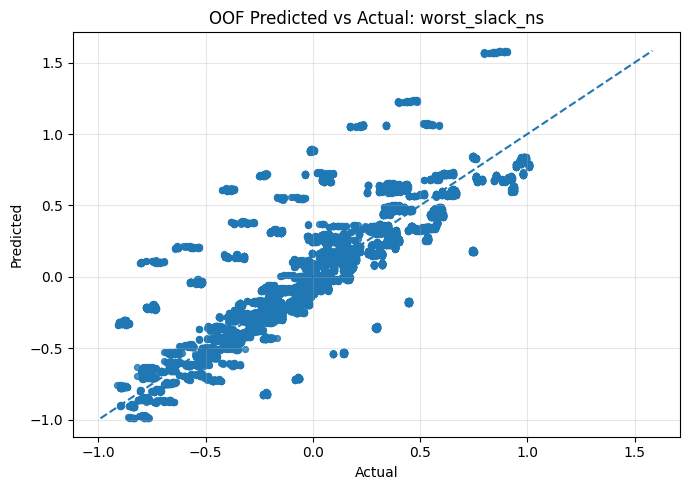

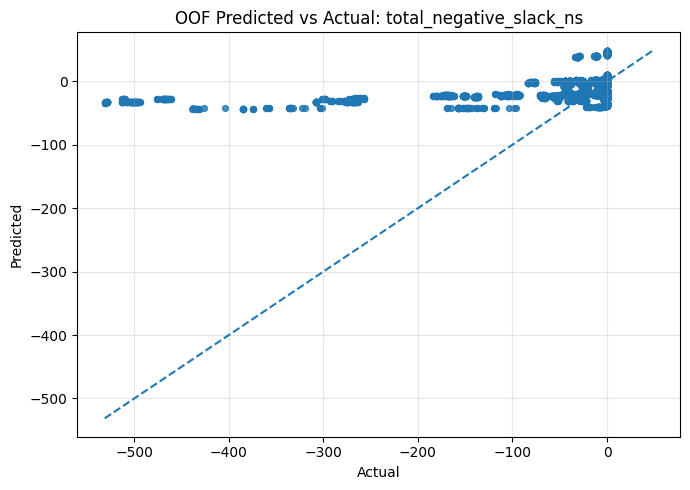

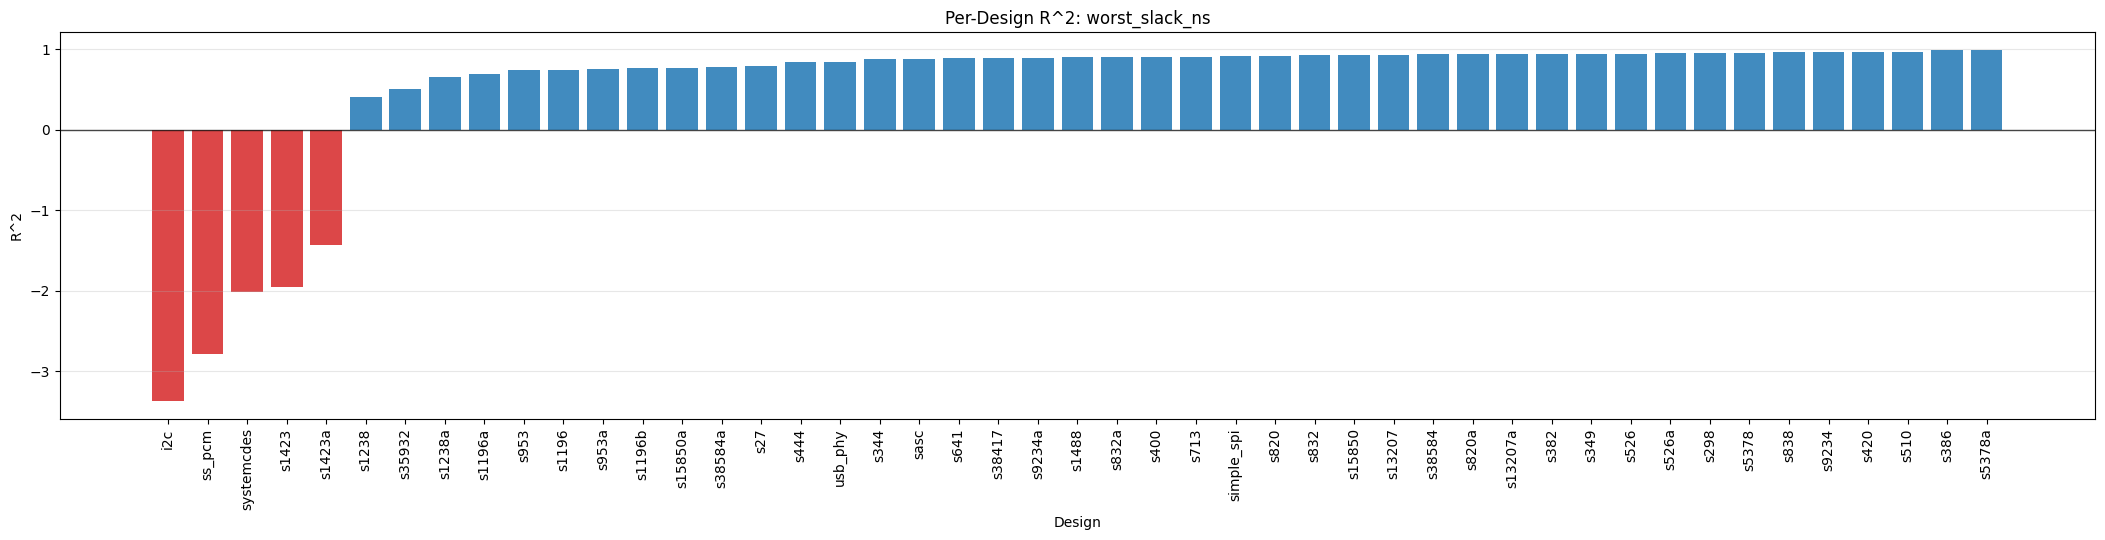

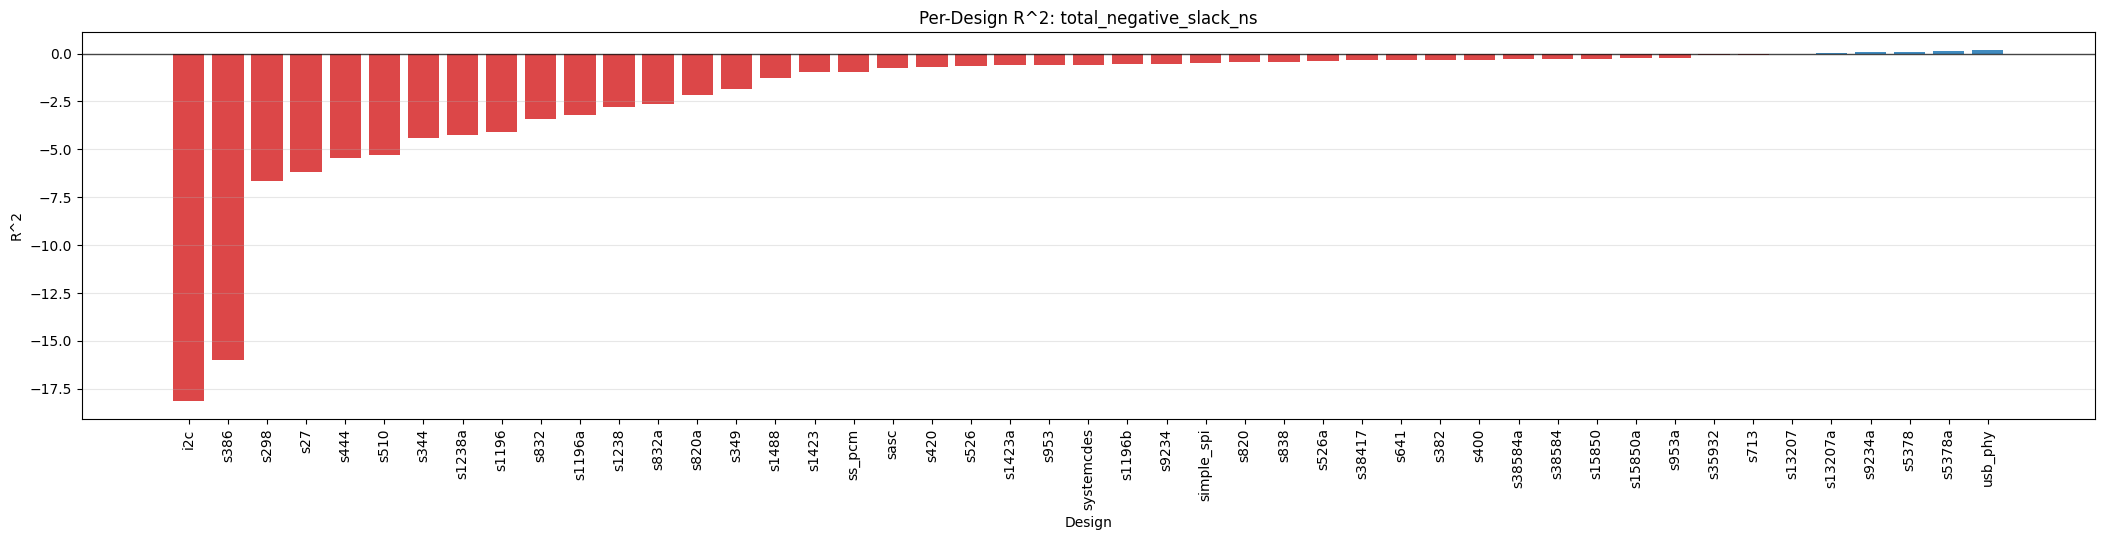

Run summary:


,item,value
0,model,linear_regression
1,split_mode,group_k_fold_design
2,requested_num_folds,5
3,num_folds,5
4,total_rows,13536
5,total_designs,47
6,use_fixed_seed,True
7,random_seed,123
8,loss_name,mse
9,smooth_l1_beta,1.0


Fold summary:


,fold,train_rows,test_rows,train_design_count,test_design_count,train_designs,test_designs
0,1,10656,2880,37,10,"i2c, s1196a, s1196b, s1238, s1238a, s13207a, s...","s1196, s13207, s15850, s349, s38584a, s510, s6..."
1,2,10656,2880,37,10,"s1196, s1196a, s1196b, s1238, s13207, s13207a,...","i2c, s1238a, s1488, s344, s38584, s444, s5378a..."
2,3,10944,2592,38,9,"i2c, s1196, s1196a, s1196b, s1238a, s13207, s1...","s1238, s1423a, s298, s38417, s420, s5378, s820..."
3,4,10944,2592,38,9,"i2c, s1196, s1196a, s1238, s1238a, s13207, s13...","s1196b, s1423, s27, s382, s400, s526a, s820, s..."
4,5,10944,2592,38,9,"i2c, s1196, s1196b, s1238, s1238a, s13207, s14...","s1196a, s13207a, s15850a, s35932, s386, s526, ..."


Cross-validation summary:


...

,design_name,fold,target,design_rows,r2,mae,rmse,true_min,true_max,true_mean,pred_mean,mean_error
0,i2c,2,total_negative_slack_ns,288,-18.134523,49.471157,50.397285,-33.426956,0.000000,-7.131220,42.339935,49.471157
1,s386,5,total_negative_slack_ns,288,-16.011742,4.348295,4.811832,-3.118498,0.000000,-0.746757,3.601539,4.348295
2,s298,3,total_negative_slack_ns,288,-6.649687,2.271035,3.138094,-3.157489,0.000000,-0.592838,1.352996,1.945834
3,s27,4,total_negative_slack_ns,288,-6.198781,0.408240,0.460855,-0.465295,0.000000,-0.081775,-0.405580,-0.323805
4,s444,2,total_negative_slack_ns,288,-5.466405,3.511648,4.231196,-4.594910,0.000000,-0.891654,2.619994,3.511648
...,...,...,...,...,...,...,...,...,...,...,...,...
89,s9234,4,worst_slack_ns,288,0.965030,0.058285,0.068294,-0.523183,0.601084,-0.044771,-0.100573,-0.055802
90,s420,3,worst_slack_ns,288,0.967196,0.038717,0.054788,-0.304993,0.613726,0.098335,0.135853,0.037519
91,s510,1,worst_slack_ns,288,0.967928,0.059228,0.063702,-0.297946,0.787997,0.149302,0.090074,-0.059228
92,s386,5,worst_slack_ns,288,0.985498,0.027839,0.038178,-0.305959,0.652468,0.115376,0.119828,0.004452


Training summary:


,fold,target,best_epoch,best_test_r2,completed_epoch
0,1,worst_slack_ns,300,0.918806,300
1,1,total_negative_slack_ns,300,0.085293,300
2,2,worst_slack_ns,59,0.169583,300
3,2,total_negative_slack_ns,300,0.039835,300
4,3,worst_slack_ns,300,0.463030,300
5,3,total_negative_slack_ns,300,0.071699,300
6,4,worst_slack_ns,76,0.757875,300
7,4,total_negative_slack_ns,1,-0.224420,300
8,5,worst_slack_ns,89,0.913368,300
9,5,total_negative_slack_ns,300,0.145669,300


Fold peak summary:


,target,peak_of_average_curve_r2,peak_of_average_curve_epoch,mean_fold_peak_r2,std_fold_peak_r2,mean_fold_peak_epoch
0,worst_slack_ns,0.6208,95,0.6445,0.3236,164.8
1,total_negative_slack_ns,-0.0526,300,0.0236,0.1439,240.2


In [12]:
for idx, target_name in enumerate(TARGET_COLUMNS):
    true_vals = oof_truth[:, idx]
    pred_vals = oof_pred[:, idx]

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.scatter(true_vals, pred_vals, s=18, alpha=0.8)
    lower = min(true_vals.min(), pred_vals.min())
    upper = max(true_vals.max(), pred_vals.max())
    ax.plot([lower, upper], [lower, upper], linestyle="--", linewidth=1.5)
    ax.set_title(f"OOF Predicted vs Actual: {target_name}")
    ax.set_xlabel("Actual")
    ax.set_ylabel("Predicted")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    scatter_plot_path = RUN_DIR / f"predicted_vs_actual_scatter_{target_name}.png"
    fig.savefig(scatter_plot_path, dpi=200, bbox_inches="tight")
    plt.show()

for target_name in TARGET_COLUMNS:
    target_design_metrics = design_metrics_table[design_metrics_table["target"] == target_name].copy()
    design_plot_order = target_design_metrics.sort_values("r2")["design_name"].tolist()
    target_design_metrics["design_name"] = pd.Categorical(
        target_design_metrics["design_name"],
        categories=design_plot_order,
        ordered=True,
    )
    target_design_metrics = target_design_metrics.sort_values("design_name")

    fig, ax = plt.subplots(figsize=(max(16, len(design_plot_order) * 0.45), 5.5))
    bar_colors = ["tab:red" if value < 0 else "tab:blue" for value in target_design_metrics["r2"]]
    ax.bar(target_design_metrics["design_name"].astype(str), target_design_metrics["r2"], color=bar_colors, alpha=0.85)
    ax.axhline(0.0, color="black", linewidth=1.0, alpha=0.7)
    ax.set_title(f"Per-Design R^2: {target_name}")
    ax.set_xlabel("Design")
    ax.set_ylabel("R^2")
    ax.grid(True, axis="y", alpha=0.3)
    ax.tick_params(axis="x", rotation=90)
    plt.tight_layout()

    per_design_plot_path = RUN_DIR / f"per_design_r2_bar_chart_{target_name}.png"
    fig.savefig(per_design_plot_path, dpi=200, bbox_inches="tight")
    plt.show()

run_summary_table = pd.DataFrame([
    {"item": "model", "value": "linear_regression"},
    {"item": "split_mode", "value": "group_k_fold_design"},
    {"item": "requested_num_folds", "value": NUM_FOLDS},
    {"item": "num_folds", "value": n_splits},
    {"item": "total_rows", "value": len(rows)},
    {"item": "total_designs", "value": len(unique_designs)},
    {"item": "use_fixed_seed", "value": USE_FIXED_SEED},
    {"item": "random_seed", "value": RANDOM_SEED if USE_FIXED_SEED else None},
    {"item": "loss_name", "value": LOSS_NAME},
    {"item": "smooth_l1_beta", "value": SMOOTH_L1_BETA},
    {"item": "peak_epoch_worst_slack_ns", "value": peak_epoch_by_target.get("worst_slack_ns")},
    {"item": "peak_epoch_total_negative_slack_ns", "value": peak_epoch_by_target.get("total_negative_slack_ns")},
])

all_design_r2_table = design_metrics_table.sort_values(["target", "r2", "design_name"]).reset_index(drop=True)

print("Run summary:")
display(run_summary_table)

print("Fold summary:")
display(fold_info_table)

print("Cross-validation summary:")
display(metrics_table)

print("OOF metrics:")
display(oof_metrics_table)

print("Per-design metric summary:")
display(design_metrics_summary_table)

print("All designs by per-design R^2:")
display(all_design_r2_table)

print("Training summary:")
display(training_summary_table)

print("Fold peak summary:")
display(fold_peak_summary_table)



In [13]:
import time

prediction_time_rows = []

for target_name in TARGET_COLUMNS:
    best_run = best_run_by_target[target_name]
    model = nn.Linear(best_run["input_dim"], 1).to(DEVICE)
    model.load_state_dict(best_run["state_dict"])
    model.eval()

    sample_x = torch.tensor(best_run["sample_input"], dtype=torch.float32, device=DEVICE)

    with torch.no_grad():
        _ = model(sample_x)
        if DEVICE.type == "cuda":
            torch.cuda.synchronize()

        start = time.perf_counter()
        for _ in range(100):
            pred = model(sample_x)
        if DEVICE.type == "cuda":
            torch.cuda.synchronize()
        avg_time_ms = ((time.perf_counter() - start) / 100.0) * 1000.0

    prediction_time_rows.append({
        "target": target_name,
        "best_fold": best_run["fold"],
        "design_name": best_run["sample_design_name"],
        "true_value": best_run["sample_true_value"],
        "predicted_value": float(pred.squeeze().item()),
        "avg_prediction_time_ms": avg_time_ms,
        "best_test_r2": best_run["best_test_r2"],
    })

prediction_time_table = pd.DataFrame(prediction_time_rows)
print("Simple prediction timing using the best saved model for each target:")
display(prediction_time_table.round(6))


Simple prediction timing using the best saved model for each target:


,target,best_fold,design_name,true_value,predicted_value,avg_prediction_time_ms,best_test_r2
0,worst_slack_ns,1,s1196,-0.386084,-0.377930,0.014777,0.918806
1,total_negative_slack_ns,5,s1196a,-6.886778,-0.242893,0.019997,0.145669
